Tasks:
1. Why is the circuit_description reversed w.r.t to the rotations returned by the given_decomposition
2. Check the minus sign in the analytical $U=0$ limit solution.
3. Use the P function in the implementation

# One-Dimensional Fermi-Hubbard Model

## Overview

## Introduction
The Fermi-Hubbard model is a fundamental corner step of condensed matter physics, describing the interplay between kinetic energy and repulsion interaction between electrons in a solid. Although very simple, in certain parameter regimes, the model showcases a variety strongly correlated phenomena, such as the metal-insulator transition (Mott physics), antiferromagnetism, inhomogeneous phases, and unconventional Fermi liquids.

In order to motivate or conceptually derive the model, consider of a metalic material composed of atoms organized in a regular pattern, i.e., a lattice. We assume the temperature is sufficiently low, so the that the vibrations of the atoms can be neglected and the atoms are essentially held in a fix position in the  lattice sites. Moreover, typically each atom has a handful of relevant energy levels, however, in order to simplify the problem we will consider only a single energy level at each lattice site (one energy level per atom). In the  metal, valance electrons move freely between the metal atoms, leading to the expected conductive behaviour. The movement of the electrons between the sites is dictated by the overlap of the spatial wave function on different sites. Since the atomic wave-functions decay exponentially with the distance to the nuclei, we consider only the dominant contribution, giving rise to hopping of electrons only between adjacent lattice sites.
These consideration lead to the first the hopping term, constituting the kinetic energy contribution: $-J \sum_{\langle i,j \rangle, \sigma} \left ( c_{i\sigma}^\dagger c_{j\sigma} + c_{i\sigma}^\dagger c_{j\sigma}\right)$, where $c_{i\sigma}$ is the fermionic annihilation operator on the $i$'th lattice site and $\sigma =
\uparrow, \downarrow$ spin. In addition, $\langle i,j\rangle$ designates that the sum is only over nearest-neighbors.

A second contribution arises from the repulsive Coulomb interaction between two electrons. Such interaction is strongest between electrons on the same atom. We consider only this dominant contribution, adding an energy penalty of $U$, for two-electrons on the same site. In addition, Pauli's exclusion principle dictates that two electrons cannot be in the same quantum state, therefore the repulsive interaction can only be between electrons with different spins: $U \sum_{j} c_{j \uparrow}^\dagger c_{j \uparrow}  c_{j\downarrow}^\dagger c_{j\downarrow}$.

Overall, the Fermi-Hubbard Hamiltonian is given by: $$H_{HF} = -J \sum_{\langle i,j \rangle, \sigma} \left ( c_{i\sigma}^\dagger c_{j\sigma} + c_{i\sigma}^\dagger c_{j\sigma}\right) + U \sum_{j} n_{j \uparrow}  n_{j\downarrow}~~,~~~~~~ (1)$$ where $ n_{j \sigma}= c_{j \sigma}^\dagger c_{j \sigma}$ is the number operator.


The model constitutes a key tool in the investigation of transition metal oxides, organic conductors  and cuprates, which exhibit high-temperature superconductivity and exotic quantum magnetism properties and unconventional symmetry breaking.
Despite its apparent simplicity, the model is notoriously changing, in 1D the Fermi-Hubbard model is solvable via Bethe ansatz [[2](#LiebWu)], while the 2D and 3D cases have not exact solution (for general hopping and interaction coefficients, $J$ and $U$). However, in 3D quantum phenomena are suppressed and the model typically exhibit classical behaviour, well described by mean-field theories.
Numerical studies are also limited beyond specific doping regimes (doping modifies the fraction of electrons/lattice sites). Perturbation theory becomes invalid when strong correlations between the electron emerge, while Monte-Carlo methods are restricted by the sign problem away from half filling (at half filling the number of electrons equals the number lattice sites).

## Present Notebook

The present notebook focuses on a digital simulation of the 1D Fermi-Hubbard (FH) model, following the experimental demonstration by Google AI Quantum [[1](#google_paper)].
In 1D a periodic lattice is just a chain of sites situated at a distance $a=1$ from one another. The FH Hamiltonian then becomes
$$H_{HF}^{(1D)} = -J \sum_{ j , \sigma} \left ( c_{j,\sigma}^\dagger c_{j+1,\sigma} + c_{j+1,\sigma}^\dagger c_{j,\sigma}\right) + U \sum_{j} n_{j \uparrow}  n_{j\downarrow}~~.$$

We demonstrate how the model is mapped to a qubit system, allowing a quantum computer to simulate non-trivial dynamics of a strongly correlated fermionic system. The dynamics exhibit spin-charge separation, where spin and charge excitations propagate at different velocities, in the non-equilibrium regime.
The digital nature of the simulation allows flexability and control over the initiail states, measured observables, and also enables time-reversal.
The physics of the model are conveniently analysed by measuring the evolution of the spin densities $$\rho_j^{\pm}(t) = \langle n_{j,\uparrow}\rangle \pm \langle n_{j,\downarrow} \rangle~~,$$ and spin  spread $$\kappa^{\pm}(t)=\sum_{j=1}^L |j-(L+1)/2|\rho^{\pm}_{j}(t)~~.$$
Crucially, the experimental realization in [[1](#google_paper)] showcased that such dynamics are accessible on the present Noisy Intermediate-Scale Quantum (NISQ) devices.


## Classiq Implementation

We implement the Hamiltonian simulation in three steps, utilizing Classiq's built-in functions.

1. Initial state-preparation: Efficiently prepare the ground state of a non-interacting FH system in the presence of an external spin dependent potential. The ground state is a Gaussian Fermionic state, creating a localized density peak, acting as a wavepacket source.
2. Time-evolution: Abruptly turn on the two-electron repulsion interaction and turn off the external potential, leading to dynamics governed by Hamiltonian (1). Utilizing a first-order Trotter expansion, the system is evolved in time.
3. Measurement: The spin densities are evaluated.

Repetition of these three steps many times produces the evolution of expectation values of spin-density in time, $\{\rho^{\pm}_{j}(t)\}$.

We consider a simplified model consisting of a periodic lattice of $L=4$ sites, and study the dynamics in a varying range of interaction strengths, $U/J\in [0,5]$.

We begin by importing the required software packages and defining global constants

In [1]:
# Uncomment to install openfermion python package
#!pip install openfermion

In [2]:
import numpy as np
from openfermion.circuits.slater_determinants import (
    slater_determinant_preparation_circuit,
)
from openfermion.linalg.givens_rotations import (
    fermionic_gaussian_decomposition,
    givens_decomposition,
)
from openfermion.ops import QuadraticHamiltonian

from classiq import *

In [3]:
L = 4  # number of lattice sites
M = 2 * L  # total number of fermionic modes
NUM_ITERS = 10
J = 1  # hopping strength
tau = 0.4 / J  # Trotter step time interval
T = NUM_ITERS * tau

### Preparation of a Slater Determinant State

As all ground states of non-interacting fermionic Hamiltonian, the ground state is a fermionic Gaussian state, which can be prepared in a worst-case circuit depth of $O(L^2)$ [[2](#fermionic_gaussian_state)]. Specifically, for a quadratic Hamiltonian which conserves the number of particles, the fermionic Gaussian state can be expressed as a Slater determinant.

For a general number conserving quadratic fermionic Hamiltonian $$H = \sum_{\mu\nu}c_\mu^\dagger h_{\mu\nu}c_\nu$$, where $h$ is a Hermitian matrix, known as the **one-body Hamiltonian**, and $\mu = (i,\sigma)$ (similarly $\nu$) designates both lattice site and spin quantum numbers.
By diagonalizing the single particle Hamiltonian $h= \bar{Q} D \bar{Q}^\dagger$, where $\bar{Q}$ is and $M$-by-$M$ unitary matrix and $D = \text{diag}(\epsilon_1,...,\epsilon_M)$, we obtain $H=\sum_{k=1}^M \epsilon_k d_k^\dagger d_k$, where $$d_\eta^\dagger= \sum_{\mu=1}^{M} \bar{Q}_{\mu \eta}c_\mu^\dagger~~. \tag{4}$$
Alternatively, the basis transformation can be expressed in terms of the single-particle transformation, $U\mathbf{c}^\dagger = \mathbf{d}^\dagger~,$ where $\mathbf{c}^\dagger = \{c_1^\dagger,\dots,c_M^\dagger\}^T$ and similarly for $\mathbf{d}^\dagger$.

For a fixed particle number $N$ the ground state is given by
$$|\psi_{g.s}\rangle =\Pi_{k} {\cal U}c_k^\dagger |0^M\rangle =  \Pi_{k=1}^M d_k^\dagger |0^M\rangle ~~,$$
where $i$ iterates over the occupied fermionic modes and ${\cal U} c_j^\dagger {\cal U}^\dagger = U_{[j,:]} \mathbf{d}^\dagger =  d_j^\dagger$.
The diagonalization of $h$ scales only polynomially with the number of lattice sites, $O(L^3)$ and can be efficiently done on a classical computer.

In order to prepare the desired ground state we focus on a part of $\bar{Q}$ which corresponds to the occupied modes, and denote the  $N$ by $M$ matrix describing these modes by $Q = (\bar{Q}^T)_{[{\text{occupied modes}},:]}$. This identification leads to an alternative form for Eq. (4), for the occupied modes we have $$d_\eta^\dagger= \sum_{\mu=1}^{M} {Q}_{\eta \mu}c_\mu^\dagger~~.$$

An efficient quantum circuit for the ground state preparation can be obtained by a modified QR decomposition of $Q$, using a product of elementary two-mode rotations, called Given rotations. Each rotation can be expressed as
$$
\begin{pmatrix}
\mathcal{G}c_k^\dagger\mathcal{G}\\
\mathcal{G}c_j^\dagger\mathcal{G}
\end{pmatrix}
=
G(\theta,\varphi)\,
\begin{pmatrix}
c_k\\
c_j
\end{pmatrix}~~,
 $$
and the form of a Given rotation is  $$G_{jk}(\theta,\varphi) = \begin{pmatrix}
\cos(\theta) & -e^{i\varphi}\sin(\theta)\\
\sin(\theta) & e^{i\varphi}\cos(\theta)
\end{pmatrix}~~. $$

To simplify the decomposition we begin by utilizing the invariance of the Slater determinant (up to a global phase) under the mapping ${Q}\rightarrow V{Q}$, where $V$ is a unitary transformation. For the transformation of basis to be valid we require that the first $N$ rows of $VQ$ are equal to $U$, or alternatively $$V{Q}U^\dagger = (I_N, \boldsymbol{0})~~.$$ Each Given transformation operates only on two columns and it's parameters, $\theta$ and $\phi$ are set so to nullify elements in the upper right part of the matrix. Due to the orthogonality of the rows of $Q$, some transformations nullify more than a single matrix element. As a result, the total number of required Given transformations are $N_G = N(M-N)$, where $N$ is the number of electrons and $M$ is the number of fermionic modes. The diagonalization procedure results in a product of Given rotations $$U = G_{N_G}\cdots G_2 G_1~~.$$

After the Jordan-Wigner transformation, each two-mode ($j,k$) rotations correspond to a rotation in the single particle subspace of the two qubits $j$ and $k$ ($|01\rangle$ and $|10\rangle$). This completely, defines the state preparation circuit in terms of a sequence two-qubit rotations.
The gate complexity is $O(N_G) = O(N^2)$ (worst case achieved for $M=N/2$), and parallelization leads to a circuit depth of $M-1$.

#### Given Rotations Example
In order to understand the state preparation algorithm, we first show how Given rotations are utilized to diagonalize a simple one-body Hamiltonian.

Consider a simple $4$-by-$4$ Hermitian matrix, representing a one-body Hamiltonian:
$$h =
\begin{pmatrix}
\varepsilon_0 & t_{01} & 0 & t_{03} \\
t_{01} & \varepsilon_1 & t_{12} & 0 \\
0 & t_{12} & \varepsilon_2 & t_{23} \\
t_{03} & 0 & t_{23} & \varepsilon_3
\end{pmatrix}
 $$

In [4]:
## Defining the single-body Hamiltonian
# Onsite energies
eps0, eps1, eps2, eps3 = 0.8, -0.4, 0.3, -0.1

# Hopping amplitudes (real for simplicity)
t01 = 0.25
t12 = -0.35
t23 = 0.20
t03 = 0.15

# 4x4 Hermitian one-body matrix h_{pq}
h = np.array(
    [
        [eps0, t01, 0.0, t03],
        [t01, eps1, t12, 0.0],
        [0.0, t12, eps2, t23],
        [t03, 0.0, t23, eps3],
    ],
    dtype=complex,
)

We employ the methods of OpenFermion's `QuadraticHamiltonian` class in order to extract the Given rotations.
The number conserving quadratic Hamiltonian is then diagonalized utilizing a Bogoliubov transformation, leading to the `orbital_energies` and a `transformation_matrix`.

In [5]:
# Number-conserving quadratic Hamiltonian (no pairing term)
qh = QuadraticHamiltonian(h, constant=0.0)
orbital_energies, transformation_matrix, constant = (
    qh.diagonalizing_bogoliubov_transform()
)

# Taking the number of electrons to be equal to be two
occupied_orbitals = np.where(orbital_energies < 0.0)[0]
slater_determinant_matrix = transformation_matrix[occupied_orbitals]

E, Qbar = np.linalg.eigh(h)
assert np.allclose(transformation_matrix, Qbar.T)

We extract the given rotations utilizing OpenFermion's `given_decomposition`, returning a list of tuples: `[(G_1,G_2),(G_3,),...]`. Each tuple includes the Given rotations which can be operated in parallel. The Given rotations are encoded as a tuple: $G_k = (i_k,j_k,\theta_k,\phi_k)$, where $i_k$ and $i_k$ are the columns of $U^\dagger$ which the Given rotation $G_k^\dagger$ is operated on from the right (see calculation below).

In [6]:
rotations, V, diag = givens_decomposition(slater_determinant_matrix)

We introduce two utility functions to demonstrate the decomposition, `given_gate` implements the two-by-two matrix and `build_U_from_rotations`, gathers all the Given rotations to create $U$.

In [7]:
def givens_gate(theta: float, phi: float) -> np.ndarray:
    """
    Givens rotation:
     G(i,j,theta, phi) =    [[ cos(theta), -e^{i phi} sin(theta)],
                            [ sin(theta),  e^{i phi} cos(theta)]]
    """
    c = np.cos(theta)
    s = np.sin(theta)
    e = np.exp(1j * phi)
    return np.array([[c, -e * s], [s, e * c]], dtype=complex)


def build_U_from_rotations(M: int, rotations) -> np.ndarray:
    """
    Reconstruct U (M x M) from OpenFermion 'givens_rotations' list.

    OpenFermion applies these to columns during decomposition; updating columns
    by right-multiplying with G^\dagger reproduces the same effect.
    """
    U_dagger = np.eye(M, dtype=complex)
    for parallel_ops in rotations:
        for i, j, theta, phi in parallel_ops:
            G = givens_gate(theta, phi)
            cols = U_dagger[:, [i, j]]
            U_dagger[:, [i, j]] = cols @ G.conj().T
    return U_dagger.conj().T


def build_state_from_rotations(M: int, N: int, circuit_description: list) -> np.ndarray:
    v = np.zeros((M,), dtype=complex)
    v[:N] = np.ones_like(v[:N])
    for parallel_ops in circuit_description:
        for i, j, theta, phi in parallel_ops:
            G = givens_gate(theta, phi)
            v[[i, j]] = G @ v[[i, j]]
    return v

Next, we decompose $U$ into Given rotations: $$U = G_{N_G},\dots,G_1 $$ and verify that $V Q U^\dagger = (I,\mathbf{0})$.

In [8]:
tol = 1e-8
Q = np.asarray(slater_determinant_matrix, dtype=complex)
n, m = Q.shape

U = build_U_from_rotations(m, rotations)

# Check V Q.T U^† = D  where D has diag entries in first m columns and zeros elsewhere
D = np.zeros((n, m), dtype=complex)
D[np.arange(n), np.arange(n)] = diag

A = V @ Q @ U.conj().T

# Normalize to (I,0) by removing the diagonal unitary on the left:
# Let Dm = diag(diag) (m x m). Then Dm^† (V Q U^†) = (I,0).
# So define V' = Dm^† V.
Dm_dag = np.diag(
    np.conjugate(diag)
)  # Dm^† since diag entries are unit-modulus in theory

Vprime = Dm_dag @ V

I0 = np.zeros((n, m), dtype=complex)
I0[:, :n] = np.eye(n, dtype=complex)

B = Vprime @ Q @ U.conj().T
assert np.allclose(A, D, atol=tol, rtol=tol)
assert np.allclose(B, I0, atol=tol, rtol=tol)

State preparation check

In [9]:
# State preparation check for the single excitation subspace
slater_determinant_matrix = transformation_matrix[[0]]
rotations, V, diag = givens_decomposition(slater_determinant_matrix)
circuit_description = reversed(rotations)
ground_state = build_state_from_rotations(m, n, circuit_description)
assert np.allclose(h @ Qbar[:, 0], E[0] * Qbar[:, 0], atol=tol, rtol=tol)

### Initial State Preparation

The initial state is chosen to be the ground state of the non-interacting (i.e, quadratic in the fermionic creation/annihilation operators) Hamiltonian $$H_{0} =-J \sum_{j, \sigma} \left ( c_{j,\sigma}^\dagger c_{j+1,\sigma} + c_{j+1,\sigma}^\dagger c_{j,\sigma}\right) + \sum_{j,\sigma}\epsilon_{j,\sigma}n_{j,\sigma} ~~,$$ where the spin-up fermions feel a Gaussian attractive potential $$\epsilon_{j,\uparrow} = -\lambda \exp \left[ -\frac{(j-m)^2}{2 w^2}\right]~~,$$ where spin-down fermions feel no potential, $\epsilon_{j,\downarrow}$. The parameters $\lambda$, $m$ and $w$ dictate the precise shape and strength of the potential.
Such potential creates a localized density peak of spin-up fermions and a flatter distribution for the spin-down fermions. As a result, the simulation begins with localized charge and spin densities. This state is generally not an eigenstate of the interacting Hamiltonian, constituting a highly excited (non-equilibrium) of the interacting system.


We begin by defining a function mapping lattice and spin degrees of freedom to qubit number, these will assist us to associate fermionic degrees of freedom to the corresponding qubits in the quantum variables.

In [10]:
def qubit_idx(site: int, spin: int):
    """
    Maps lattice site and spin to qubit indices.

    Args:
        site (int): Lattice site index, the range [0,L-1]
        spin (int): Spin index, either 0 or 1

    Returns:
        qubit_idx (int): qubit index
    """
    return 2 * (site % L) + (spin % 2)


def qubit_idx_to_site_and_spin(qubit_idx: int):
    """
    Maps qubit index to site and spin indices.

    Args:
        qubit_idx (int): qubit index

    Returns:
        site (int): site index
        spin (int): spin index
    """
    spin = qubit_idx % 2
    site = qubit_idx // 2
    return site, spin

Next, we introduce quantum functions that implement the state preparation circuit $U = G_{N_G}\dots G_1$.

In [11]:
@qfunc
def G(theta: float, phi: float, qba: QArray[QBit, 2]):
    """
    Implements a Given rotation on two qubits.
    """
    c = np.cos(theta)
    s = np.sin(theta)
    e = np.exp(1j * phi)
    U = [
        [1, 0, 0, 0],
        [0, c, -e * s, 0],
        [0, s, e * c, 0],
        [0, 0, 0, 1],
    ]
    unitary(U, qba)


@qfunc
def given_rotation(gate: list[int, int, float, float], qba: QArray[QBit, M]) -> None:
    """
    Implements a Given rotation on two specific qubits, i and j, from an M-qubit quantum array, qba.
    """
    i, j, theta, phi = gate
    G(theta, phi, [qba[i], qba[j]])


@qfunc
def prepare_slater_det(h: list[list[float, M], M], N: int, qba: QArray[QBit, M]):
    """
    Prepares the ground state associated with the single electron matrix h.
    The Hamiltonian satisfies H = \sum_{\mu,\nu}c_{\mu}^\dagger h_{\mu,\nu} c_{\nu}

    Args:
        h (ndarray): single electron matrix
        N (int): number of electrons
        qba (list[QBit]): list of qubits
    """
    # preparing the reference state, as the state with the first N qubits in state |1> and the rest in state |0>.
    repeat(N, lambda i: X(qba[i]))

    # diagonalizing h
    D, Qbar = np.linalg.eigh(h)
    Q = (Qbar.T)[:N, :]  # occupying the N lowest energy states
    rotations, _, _ = givens_decomposition(Q)
    # U = build_U_from_rotations(M, rotations)
    circuit_description = list(reversed(rotations))
    # ground_state = build_state_from_rotations(M, N, circuit_description)
    for parallel_ops in circuit_description:
        for gate in parallel_ops:
            given_rotation(list(gate), qba)

The circuit can be verified by considering the single excitation subspace and comparing the compared state to the analytical result.

The ground state of the single excitation subspace is up to a global phase just $$d_1^\dagger | 0^M\rangle =\sum_\mu Q_{1,\mu} c^{\dagger}_\mu | 0^M\rangle ~~,$$ which after the Jordan-Wigner transformation corresponds to the quibit state with amplitudes $$[Q_{1,1},Q_{1,2},\dots, Q_{1,M}]~~.$$

In order to prepare the initial state, we begin by constructing the initial Hamiltonian. Utility functions are defined and the Hamiltonian parameters are set.

In [12]:
def sym(A):
    """
    Symmetrizes the matrix A
    """
    return (A + A.T) / 2


def kinetic_energy(L: int, J: float) -> np.ndarray:
    """
    Builds single electron matrix of nearest-neighbor hopping term, hopping strength t, associated with an L site periodic lattice.
    """
    K = np.zeros((2 * L, 2 * L), dtype=float)
    for site in range(L):
        for spin in range(2):
            mu = qubit_idx(site, spin)
            nu = qubit_idx(site + 1, spin)
            K[mu, nu] = -J
    K = 2 * sym(K)
    return K


def spin_potential(L: int, spin=0, parameters: tuple[float] = (1, 1, 1)) -> np.ndarray:
    """
    Builds single electron , matrix associated with the external potential. Associated with an L site periodic lattice.
    """
    lam, mean, std = parameters
    V = np.zeros((2 * L, 2 * L), dtype=float)
    for site in range(L):
        mu = qubit_idx(site, spin)
        V[mu, mu] = -lam * np.exp(-((site - mean) ** 2) / (2 * std**2))
    return V


def prepare_single_electron_hamiltonian(
    L: int, J: float, parameters: tuple
) -> np.ndarray:
    return kinetic_energy(L, J) + spin_potential(L, spin=0, parameters=parameters)

In [13]:
lam = 10.0
mean = L / 2
std = L / 6
h = prepare_single_electron_hamiltonian(L, J=1, parameters=(lam, mean, std))
N = 1

In [14]:
@qfunc
def main(qba: Output[QArray[QBit, M]]) -> None:
    allocate(M, qba)
    prepare_slater_det(h, N, qba)


qprog = synthesize(main)

The state preparation quantum circuit. The Given rotation, operating on two qubits, is decomposed into the basis gates.


ADD the CIRCUIT...

In [15]:
# # single electron test
# execution_preferences = ExecutionPreferences(
#     backend_preferences=ClassiqBackendPreferences(
#         backend_name=ClassiqSimulatorBackendNames.SIMULATOR_STATEVECTOR
#     ),
# )
#
# with ExecutionSession(
#     quantum_program=qprog, execution_preferences=execution_preferences
# ) as es:
#     res = es.sample()
# # assert(np.isclose(classical_ground_state == result))

In [16]:
backend_preferences = ClassiqBackendPreferences(
    backend_name=ClassiqSimulatorBackendNames.SIMULATOR_STATEVECTOR
)


# Construct a representation of HHL model
def state_check_model(main, backend_preferences):
    qmod_state_check = create_model(
        main,
        execution_preferences=ExecutionPreferences(
            num_shots=1, backend_preferences=backend_preferences
        ),
    )
    return qmod_state_check

In [17]:
# Construct the quantum program
qmod_state_check = state_check_model(main, backend_preferences)
qprog_state_check = synthesize(qmod_state_check)
# show(qprog_state_check)

print("Circuit depth = ", qprog_state_check.transpiled_circuit.depth)
res_state_check = execute(qprog_state_check).result_value()

Circuit depth =  25


In [18]:
import matplotlib.pyplot as plt


def get_quantum_amplitudes(result):
    df = result.dataframe
    mask = np.abs(df["amplitude"]) > 1e-12
    filtered = df.loc[mask, ["bitstring", "amplitude"]].copy()
    amps = filtered["amplitude"].to_numpy()
    bitstring = filtered["bitstring"].tolist()  # must be integers
    # mapping the bitstrings to qubit indices in the array
    qubit_index = [[i for i, b in enumerate(s[::-1]) if b == "1"] for s in bitstring]
    qubit_index = np.array([i[0] for i in qubit_index])
    idx = np.argsort(qubit_index)
    qubit_index = qubit_index[idx]
    amps = amps[idx]
    amps = amps / np.linalg.norm(amps)

    qsol = np.zeros(M, dtype=complex)
    qsol[qubit_index] = amps
    return qsol

For the single excitation subspace we can easily compare the preparation of the quantum state with the exact diagonalization. To compare between the two we normalize the quantum solution so to cancel the difference in the global phase with respect to the classical result.

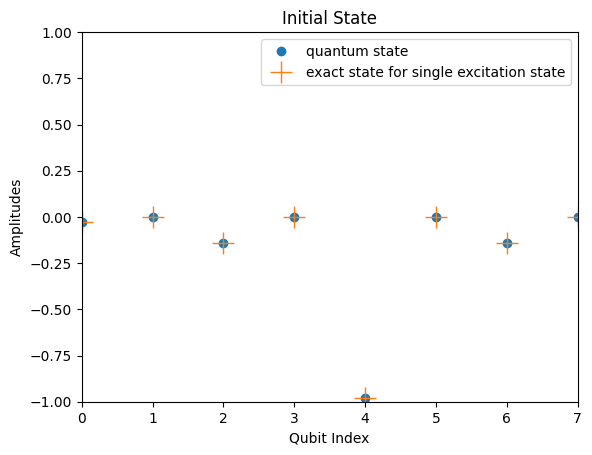

In [19]:
def quantum_solution_normalization(exact_amplitudes, result):
    qsol = get_quantum_amplitudes(result)
    global_phase = np.angle(np.vdot(qsol, exact_amplitudes))
    # Correct global phase and taking the real part
    qsol_corrected = np.real(np.exp(1j * global_phase) * qsol)

    return qsol_corrected


# Quantum amplitudes
quantum_amplitudes = get_quantum_amplitudes(res_state_check)

# Exact diagonalization
E0, V0 = np.linalg.eigh(h)
exact_ground_state = V0[:, 0] / np.linalg.norm(V0[:, 0])

quantum_amplitudes_corrected = quantum_solution_normalization(
    exact_ground_state, res_state_check
)
grid = np.arange(0, M)

plt.figure()
plt.title("Initial State")
plt.plot(grid, quantum_amplitudes_corrected, "o", label="quantum state")
plt.plot(
    grid,
    exact_ground_state,
    "+",
    markersize=16,
    label="exact state for single excitation state",
)
plt.xlim(0, M - 1)
plt.ylim(-1, 1)
plt.xlabel(r"Qubit Index")
plt.ylabel(r"Amplitudes")
plt.legend()
plt.show()

## Initial State for in Half-filling
In half-filling the number of electrons, $N$, equals to half the number of fermionic modes $M$.
We define the quantum model, synthesize the state preparation model.

In [20]:
@qfunc
def main(qba: Output[QArray[QBit, M]]) -> None:
    allocate(M, qba)
    prepare_slater_det(h, N, qba)


qprog = synthesize(main)

To image the ground state, we measure the charge and spin densities: $\rho_j^{\pm} = \langle n_{j,\uparrow}\rangle \pm \langle n_{j,\downarrow} \rangle$. The charge density, $\rho_j^{+}$, corresponds to the average number of electrons on the $j$'th site, while the spin density, $\rho_j^{-}$, is the net spin on the same site.

The number operator $n_\mu = c^\dagger_\mu c_\mu$ maps under the Jordan-Wigner transformation to $$n_\mu \rightarrow \frac{I-Z_{\mu}}{2}~~. $$
Therefore, the charge density maps to $$\rho_j^{+} = 1 - (\langle Z_{j,\uparrow}\rangle + \langle Z_{j,\downarrow}\rangle)/2~~,$$ while the spin density corresponds to $$ \rho_j^{-} =  (\langle Z_{j,\downarrow}\rangle - \langle Z_{j,\uparrow}\rangle)/2 ~~.$$

We introduce the functions `charge_density` and `spin_density` which allow measuring the corresponding observables.

In [21]:
def charge_density(site: int, M: int) -> SparsePauliOp:
    s = SparsePauliOp([], M)
    for spin in (0, 1):
        idx = qubit_idx(site=site, spin=spin)
        s += (Pauli.I(idx) - Pauli.Z(idx)) * 0.5
    return s


def spin_density(site: int, M: int) -> SparsePauliOp:
    s_up, s_down = SparsePauliOp([], M), SparsePauliOp([], M)
    idx_up, idx_down = qubit_idx(site=site, spin=0), qubit_idx(site=site, spin=1)
    s_up += Pauli.Z(idx_up)
    s_down += Pauli.Z(idx_down)
    return (s_down - s_up) * 0.5

Next, we execute the quantum program and measure the spin and change densities

In [22]:
initial_charge_density = np.zeros(L)
initial_spin_density = np.zeros(L)

with ExecutionSession(qprog) as es:
    for site in range(L):
        initial_charge_density[site] = np.real(
            es.estimate(charge_density(site, M)).value
        )
        initial_spin_density[site] = np.real(es.estimate(spin_density(site, M)).value)

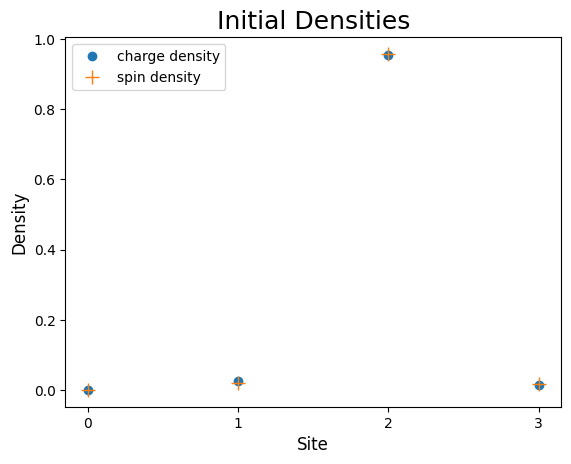

In [23]:
sites = np.arange(0, L)
plt.figure()
plt.title("Initial Densities", fontsize=18)
plt.plot(sites, initial_charge_density, "o", label="charge density")
plt.plot(sites, initial_spin_density, "+", markersize=10, label="spin density")
plt.xlabel("Site", fontsize=12)
plt.ylabel("Density", fontsize=12)
plt.xticks(sites)
plt.legend()
plt.show()

The attractive potential is centered around `mean` = $2$, therefore the initial charge and spin densities form a peak around that site $2$.

### Time-Evolution

The propagation stage approximates the time-evolution operator $U = \exp(-i H t)$, where
$$ H =-J \sum_{j, \sigma} \left ( c_{j,\sigma}^\dagger c_{j+1,\sigma} + c_{j,\sigma}^\dagger c_{j+1,\sigma}\right) + U \sum_{j} n_{j \uparrow}  n_{j\downarrow}  \tag{3}$$ is the 1D version of Eq. (1), where periodic conditions are assumed, $j\equiv j \mod L$.

The propagation of the initial state with respect to Eq. (3), simulates an effective quench of the system at initial time, abruptly changing the Hamiltonian $H_0\rightarrow H$. As a consequence, the initial state is a highly excited state of $H$.

In order to minimize the circuit depth of the quantum circuit it is beneficial to decompose the Hamiltonian into four sets of terms, where all the operators in a set commute with one another. The terms correspond to an even and odd edge hopping terms and even and odd site interaction terms:
$$H = H_{\text{hop-even}} +H_{\text{hop-odd}} +H_{\text{int-even}}+ H_{\text{int-odd}} ~~.$$
The odd hopping Hamiltonian term includes the hopping terms between $1\leftrightarrow
2$ and $3\leftrightarrow
4$ neighbouring sites ($j$ is odd in Eq. (3)), while the odd hopping term includes the odd edge pairs ($2\leftrightarrow
3$, $4\leftrightarrow
1$, even $j$).

The evolution operator $U$ is approximated by a first-order Trotter expansion, where each Trotter step consists of five stages.
$$U = e^{-i H t} \approx \left(e^{-i H \tau}\right)^{t/\tau}~~, $$ with $$e^{-i H \tau}  \approx e^{-i H_{\text{hop-even}}\tau} e^{-i H_{\text{int-even}}\tau} e^{-i H_{\text{int-odd}}\tau} e^{-i H_{\text{hop-odd}}\tau}. $$
Each component in the Trotter step can be achieved by simultaneous application (circuit depth of one) of simple two-qubit gates.

An additional algorithmic trick simplifying the circuit and reducing the circuit depth even further. Between the even and odd interaction terms a fermionic mode swap operation is conducted,  effectively performing a cyclic shifting of the fermionic modes. Crucially, this operation swaps the logical ordering of the qubits, while preserving the fermionic parity sign (using an iSWAP gates). Alternatively, the operation modifies the mapping between physical qubits and logical fermionic. As a result, the Hamiltonian terms are interpreted relative to the new ordering, effectively swapping the odd and even edge.
The incorporation of the swap mode operation, allows parallelism, locality (only nearest neighbor gates, bypassing the need for long Jordan Wigner strings).
After the application of $\exp(-i H_{\text{hop-even}}\tau)$ an inverse fermionic mode swap is needed to swap the even and odd edges back, allowing application of the consecutive Trotter step. Since the even edge hopping term commutes with the inverse fermionic mod swap, these operations are merged to a single stage.

Overall, the time-evolution involves iteration (each iteration corresponds to a single Trotter step) of a five-step procedure:
1. Hopping operation on odd edges.
2. Interaction on odd sites
3. Fermionic mode swap
4. Interaction on even sites
5. Hopping operation on even sites + inverse fermionic mode swap


Setting the Hamiltonian parameters

In [24]:
U = 2 * J  # J is set to unity in the beginning of the notebook

We begin by defining utility functions

In [25]:
## Rotation in the |01>, |10> subspace


# K(theta) = exp(-i*(theta/2)*(XX + YY))
@qfunc
def K(theta: float, target: QArray[QBit, 2]) -> None:
    Unitary = [
        [1, 0, 0, 0],
        [0, np.cos(theta), -1j * np.sin(theta), 0],
        [0, -1j * np.sin(theta), np.cos(theta), 0],
        [0, 0, 0, 1],
    ]
    unitary(Unitary, target)


# P(phi) = exp(-i*(phi/2)*(I-Z_{\mu}-Z_{\nu}+Z_{\mu}Z_{\nu}))
@qfunc
def P(phi: float, target: QArray[QBit, 2]) -> None:
    RZ(-phi, target[0])
    RZ(-phi, target[1])
    RZZ(phi, target)

To propagate the system state we transform the fermion Hamilotonian to a qubit representation utilizing the Jordan-Wigner transformation.

A single hopping term transforms as
$$c_{\mu}^{\dagger} c_{\nu} + c_{\mu}^{\dagger} c_{\nu}  \xrightarrow{\text{JW}} \frac{1}{2} \left( X_{\mu}X_{\nu} + Y_{\mu}Y_{\nu} \right)~~,$$
while an interaction term gives $$n_{\mu}n_{\nu}  \xrightarrow{\text{JW}} = \frac{1}{4}\left(I -Z_\mu -Z_\nu + Z_\mu Z_\nu \right)~~. $$

As a consequence, the five stages can be performed by implementation of the basic unitaries $K(\theta)= \exp\left(-i \frac{\theta}{2}\left(XX + YY \right)\right)$ and $P(\phi) = \exp\left(-i \frac{\phi}{2}\left(I-Z_{\mu}-Z_{\nu}+Z_{\mu}Z_{\nu} \right)\right)$. The functions `K` and `P` above implement the corresponding unitary transformations.

The first stage, including odd hopping terms, is obtained by simultaneous application of $K(\theta = -\tau J)$ on different paris of qubits. Similarly, the second and fourth stages, involving the odd and even interactions are achieved with simultaneous application of $P(\phi = \tau U/2)$ on the corresponding pairs of qubits. The third stage, constituting the fermionic mode swap, is implemented by simultaneous iSWAP gates which is equivalent to $K(\theta = -\pi/2)$. The last stage includes a merge of even-edge hopping operation, and an inverse fermionic mode swap operation. Naturally, since these operation commute, the transformation is obtained by $K(\theta = -\tau J + \pi/2)$ two-qubit gates.

We implement the simultaneous operations on the qubit array utilizing Classiq's built-in `repeat` function within the `hop` and `interact` functions.

In [26]:
def hop(pairs: list[tuple[int, int]], theta: float, qba: QArray[QBit, M]) -> None:
    for spin in {0, 1}:
        for pair in pairs:
            site1, site2 = pair
            K(
                theta,
                [
                    qba[qubit_idx(site=site1, spin=spin)],
                    qba[qubit_idx(site=site2, spin=spin)],
                ],
            )


def interact(sites: list[int], phi, qba: QArray[QBit, M]) -> None:
    for spin in {0, 1}:
        for site in sites:
            RZ(-phi, qba[qubit_idx(site=site, spin=spin)])
            RZ(-phi, qba[qubit_idx(site=site, spin=spin + 1)])
            RZZ(
                phi,
                [
                    qba[qubit_idx(site=site, spin=spin)],
                    qba[qubit_idx(site=site, spin=spin + 1)],
                ],
            )
            # P(phi,
            #    [qba[qubit_idx(site=site, spin=spin)],
            #    qba[qubit_idx(site=site, spin=spin+1)]]
            # )

Defining the odd and even pairs and sites

In [27]:
ODD_PAIRS = [(i, (i + 1) % L) for i in range(0, L, 2)]
EVEN_PAIRS = [((i + 1) % L, i) for i in range(0, L, 2)]
ODD_SITES = list(range(0, L, 2))
EVEN_SITES = list(range(1, L, 2))

Gathering all the stages together to form the Trotter step

In [28]:
def trotter_step(tau: float, J: float, U: float, qba: QArray[QBit, L]) -> None:

    # stage 1 - hopping on odd-edge pairs
    hop(pairs=ODD_PAIRS, theta=-tau * J, qba=qba)

    # stage 2 - interaction on odd site
    interact(sites=ODD_SITES, phi=tau * U / 2, qba=qba)

    # stage 3 - fermionic mode swap
    hop(pairs=EVEN_PAIRS, theta=-np.pi / 2, qba=qba)

    # stage 4 - interaction on even sites
    interact(sites=EVEN_SITES, phi=tau * U / 2, qba=qba)

    # stage 5 - hopping on even-edge pairs and inverse fermionic mode swap
    hop(pairs=EVEN_PAIRS, theta=-tau * J + np.pi / 2, qba=qba)

### Propagation and Execution

In [29]:
@qfunc
def main(qba: Output[QArray[QBit, M]], num_iter: CInt) -> None:
    allocate(M, qba)
    prepare_slater_det(h, N, qba)
    power(num_iter, lambda: trotter_step(tau, J, U, qba))


qprog = synthesize(main)
show(qprog)

Quantum program link: https://platform.classiq.io/circuit/3AKqbEZo5cdLGF4Nvoem2c2EQfH


#### Measurement

The physics of the model are analyzed by measuring the charge and spin densities and the spin spreads $\kappa^{\pm}(t)$, defined above.
The number operators map to local Pauli operators $n_{\mu} = c^\dagger_{\mu}c_{\mu} = (1-Z_\mu)/2$, where $\mu=(j,\sigma)$ encodes a site, spin pair.


In [30]:
def spread(density: list, L: int) -> float:
    s = 0
    for site in range(L):
        s += np.abs(site - (L + 1) / 2) * density[site]
        return s


def charge_spread(density: list, L: int) -> float:
    s = 0
    for site in range(L):
        s += np.abs(site - (L + 1) / 2) * density[site]
        return s


def spin_spread(density: list, L: int) -> float:
    s = 0
    for site in range(L):
        s += np.abs(site - (L + 1) / 2) * density[site]
        return s

In [31]:
charge_density_mat = np.zeros((L, NUM_ITERS))
spin_density_mat = np.zeros((L, NUM_ITERS))


with ExecutionSession(qprog) as es:
    for iter in range(NUM_ITERS):
        for site in range(L):
            charge_density_mat[site, iter] = np.real(
                es.estimate(charge_density(site, M), {"num_iter": iter}).value
            )
            spin_density_mat[site, iter] = np.real(
                es.estimate(spin_density(site, M), {"num_iter": iter}).value
            )

In [32]:
times = np.array([tau * i for i in range(NUM_ITERS)])
print(f"Shown times: {times[np.array([0,4,9])]}")

Shown times: [0.  1.6 3.6]


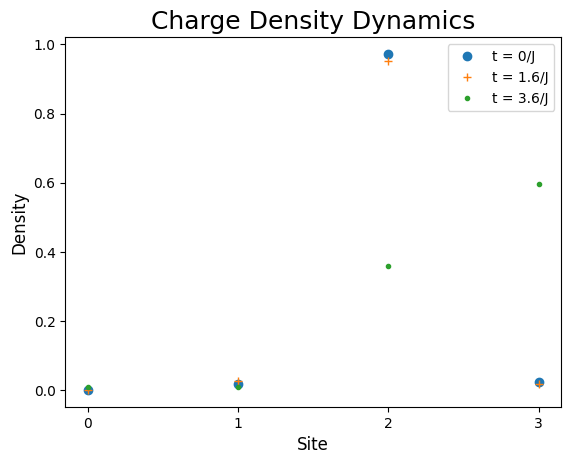

In [33]:
sites = np.arange(0, L)
plt.figure()
plt.title("Charge Density Dynamics", fontsize=18)
plt.plot(sites, charge_density_mat[:, 0], "o", label="t = 0/J")
plt.plot(sites, charge_density_mat[:, 4], "+", label="t = 1.6/J")
plt.plot(sites, charge_density_mat[:, 9], ".", label="t = 3.6/J")
plt.xlabel("Site", fontsize=12)
plt.ylabel("Density", fontsize=12)
plt.xticks(sites)
plt.legend()
plt.show()

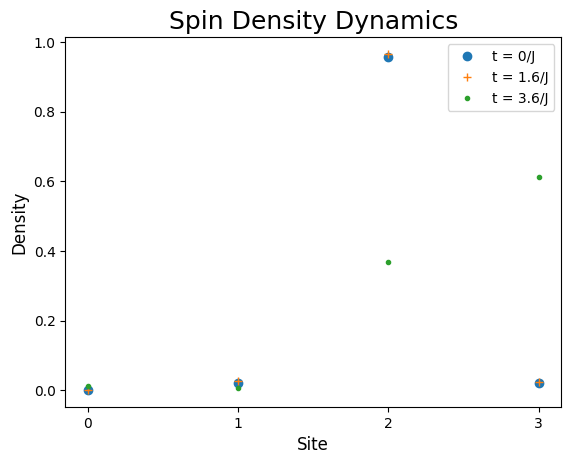

In [34]:
plt.title("Spin Density Dynamics", fontsize=18)
plt.plot(sites, spin_density_mat[:, 0], "o", label="t = 0/J")
plt.plot(sites, spin_density_mat[:, 4], "+", label="t = 1.6/J")
plt.plot(sites, spin_density_mat[:, 9], ".", label="t = 3.6/J")
plt.xlabel("Site", fontsize=12)
plt.ylabel("Density", fontsize=12)
plt.xticks(sites)
plt.legend()
plt.show()

## Analysis - Spin Charge Seperation

## Comparison with Analytical Results

In order to validate the results, we compare the model prediction with the anlytical solutions.

There are two natural physical limits, where the model can be solved exactly and efficiently utilizing classical methods:
1. The non-interacting limit the on-site interaction vanishes $U = 0$ (alternatively $U\ll J$).
2. Vanishing hopping limit, $J=0$ (alternatively $U\gg J$).

### Non-interacting Particles
In the non-interacting limit of $U=0$, the FH Hamiltonian is a quadratic Hamiltonian. As a consequence, even in the case of site dependent hopping or hopping between non-adjacent sites the state dynamics can be solved classically in polynomial time in the number of fermionic modes $M$, utilizing standard matrix exponentiation methods.
In the case of the FH model, the solution is even simpler. In the non-interacting limit, the Hamiltonian becomes $$H^{\text{n.i}} =\sum_{\mu, \nu} c_{\mu}^\dagger M_{\mu\nu}c_{\nu} =    -J \sum_{j, \sigma} \left ( c_{j,\sigma}^\dagger c_{j+1,\sigma} + c_{j+1,\sigma}^\dagger c_{j,\sigma}\right) ~~,$$ where n.i denotes "non-interacting". The translational invariance of the Hamiltonian and the commutativity of spin up and spin down terms allows direct diagonalization by introducing the
Fourier operator basis $$ c_{j,\sigma} = \frac{1}{\sqrt{M}}\sum_{k,\sigma}c_{k,\sigma}e^{ik x_j}~~,$$ where $x_j = a j$, $a$ is the lattice spacing (distance between adjacent lattice sites) and  $k = ({\pi L}/{a})\left[-M/2,\dots,M/2-1 \right]$. In this operator basis, the Hamiltonian becomes $$H^{\text{n.i}} = \sum_{k,\sigma} \omega_{k,\sigma} c_{k,\sigma}^\dagger c_{k,\sigma}~~,~~ \text{where}~~\omega_{k,\sigma} = {-2J \cos(k a)}~~.$$ The corresponding single electron eigen states are given by the creation operators $$\ket{\phi_{k,\sigma}} = c_{k,\sigma}^\dagger | \text{vacc}\rangle~~.$$ The ground state of an $N$ electron system is obtained by occupying the eigenstates one by one.

The time-dependent expectation values of the charge and spin densities, $\langle\rho^{\pm}_j(t)\rangle$, can readily obtained by employing the Heisenberg representation of quantum mechanics. In this representation, an operator's, $O(t)$, dynamics is generated by the Heisenberg equation
$$\frac{dO(t)}{dt} = i \left[ H^{\text{n.i}}, O(t) \right]  ~~,$$ where $O(t) = U(t)^\dagger O U(t)$, where $U(t) = \exp(-i H^{\text{n.i}} t)$.
Substituting the diagonal form of $H^{\text{n.i}}$ and utilizing the fermionic anti-commutation relations $$\{c^\dagger_{\mu}, c_\nu\} = \delta_{\mu,\nu}~~, ~~\{c_{\mu}, c_\nu\} = \{c_{\mu}^\dagger, c_\nu^\dagger\} = 0~~,$$
(the Fourier fermionic operators satisfy similar commutation relations) we obtain $\dot{c}_\mu^\dagger = i M_{\nu \mu} c_{
\nu}^\dagger$, therefore $\dot{\mathbf{c}}^\dagger = i M^T \mathbf{c}^\dagger$, leading to $$\mathbf{c}^\dagger(t) = e^{i M^T t}\mathbf{c}^\dagger(0)$$


In order to evaluate the dynamics of the charges it is convenient to introduce the matrices ${\cal U}(t) = e^{-i M^T t}~~,$ and ${\cal N}$ with elements ${\cal N_{
\mu \nu}} = \langle c_{\mu}^\dagger c_\nu\rangle$  we can write the dynamics of a second order correlation as
$$\langle c_{\mu}^\dagger c_{\nu} \rangle =  \left[ {\cal{U}}^\dagger (t){\cal{N}} {\cal{U}}^T (t)\right]_{\mu \nu}~~.$$
In the one-excitation subspace, the ground state reads $|\psi_{\text{g.s}} \rangle = \sum_{\mu} V_{0,\mu}c_{\mu}^\dagger|\text{vacc}\rangle$, where $\{V_{0\mu}\}$ are the elements of the eigenstate of $M$, i.e. $M V_0 = \epsilon_0 V_0$, where $\epsilon_0$ is the grounds state energy.
As a consequence, $$ \langle c_{\mu}^\dagger c_\nu\rangle = V_{0\mu}^* V_{0\nu}~~.$$

#### Numerical Evaluation on a small model.

Defining parameters

In [45]:
L = 4  # number of lattice sites
M = 2 * L  # total number of fermionic modes
NUM_ITERS = 10
J = 1  # hopping strength
tau = 0.4 / J  # Trotter step time interval
T = NUM_ITERS * tau
U = 0
N = 1  # half-filling

Evaluate the charges numerically

In [46]:
# create the one-body hamiltonian, corresponding to the free Hamiltonian
lam = 10.0
mean = L / 2
std = L / 6
M0 = prepare_single_electron_hamiltonian(L, J=J, parameters=(lam, mean, std))
Mmat = prepare_single_electron_hamiltonian(L, J=J, parameters=(0.0, mean, std))

# evaluating the initial state and the initial two-body correlations
E, V = np.linalg.eigh(M0)
amplitudes = V[:, 0]
tol = 1e-13
amplitudes[np.abs(amplitudes) < tol] = 0
initial_correlations = np.outer(amplitudes.conj(), amplitudes)

from scipy.linalg import expm

Ucal = expm(-1j * T * Mmat.T)
Ucal[np.abs(Ucal) < tol] = 0
correlations = (
    Ucal.conj().T @ initial_correlations @ Ucal.T
)  # correlation matrix <c_mu^\dagger c_nu>

charge_density_numerical = np.zeros(L, dtype=np.complex128)
spin_density_numerical = np.zeros(L, dtype=np.complex128)


for site in range(L):
    charge_density_numerical[site] = (
        correlations[qubit_idx(site, spin=0), qubit_idx(site, spin=0)]
        + correlations[qubit_idx(site, spin=1), qubit_idx(site, spin=1)]
    )
    spin_density_numerical[site] = (
        correlations[qubit_idx(site, spin=0), qubit_idx(site, spin=0)]
        - correlations[qubit_idx(site, spin=1), qubit_idx(site, spin=1)]
    )

/var/folders/f9/dqrhj23922x926lhkszh0c5h0000gn/T/ipykernel_64367/1940816773.py:18: RuntimeWarning: divide by zero encountered in matmul
  correlations = Ucal.conj().T @ initial_correlations @ Ucal.T       # correlation matrix <c_mu^\dagger c_nu>
/var/folders/f9/dqrhj23922x926lhkszh0c5h0000gn/T/ipykernel_64367/1940816773.py:18: RuntimeWarning: overflow encountered in matmul
  correlations = Ucal.conj().T @ initial_correlations @ Ucal.T       # correlation matrix <c_mu^\dagger c_nu>
/var/folders/f9/dqrhj23922x926lhkszh0c5h0000gn/T/ipykernel_64367/1940816773.py:18: RuntimeWarning: invalid value encountered in matmul
  correlations = Ucal.conj().T @ initial_correlations @ Ucal.T       # correlation matrix <c_mu^\dagger c_nu>


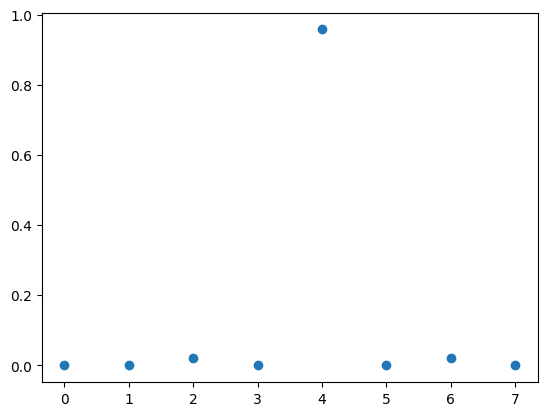

In [47]:
indicies = np.arange(M)
plt.figure()
plt.plot(indicies, np.abs(amplitudes) ** 2, "o")

In [48]:
h = prepare_single_electron_hamiltonian(L, J=J, parameters=(lam, mean, std))


@qfunc
def main(qba: Output[QArray[QBit, M]], num_iter: CInt) -> None:
    allocate(M, qba)
    prepare_slater_det(h, N, qba)
    power(num_iter, lambda: trotter_step(tau, J, U, qba))


qprog = synthesize(main)

In [49]:
charge_density_non_interaction = np.zeros((L,))
spin_density_non_interaction = np.zeros((L,))


with ExecutionSession(qprog) as es:
    for site in range(L):
        charge_density_non_interaction[site] = np.real(
            es.estimate(charge_density(site, M), {"num_iter": NUM_ITERS}).value
        )
        spin_density_non_interaction[site] = np.real(
            es.estimate(spin_density(site, M), {"num_iter": NUM_ITERS}).value
        )

#### Results

Charge density

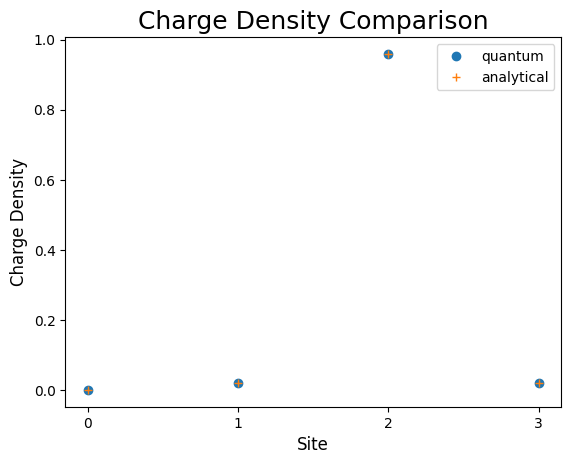

In [50]:
plt.title("Charge Density Comparison", fontsize=18)
plt.plot(sites, charge_density_non_interaction, "o", label="quantum")
plt.plot(sites, charge_density_numerical, "+", label="analytical")
plt.xlabel("Site", fontsize=12)
plt.ylabel("Charge Density", fontsize=12)
plt.xticks(sites)
plt.legend()
plt.show()

Spin Density

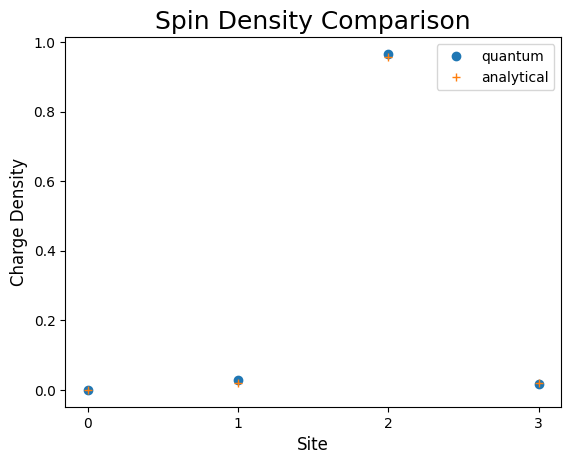

In [51]:
plt.title("Spin Density Comparison", fontsize=18)
plt.plot(sites, spin_density_non_interaction, "o", label="quantum")
plt.plot(sites, spin_density_numerical, "+", label="analytical")
plt.xlabel("Site", fontsize=12)
plt.ylabel("Charge Density", fontsize=12)
plt.xticks(sites)
plt.legend()
plt.show()

### Vanishing hopping limit
The other extreme is obtained when the onsite interactions is much larger than the hopping constant. In this regime interaction dominate the physics and supress hopping between adjacent sites, allowing us to take $J=0$.
The FH Hamiltonian then becomes a sum of local commuting terms, diagonal in the Fock basis (eigenstates of the number operators $\{n_{\mu}\}$).
The Hamiltonian reduces to $$ H^{\text{n.h}} =  U \sum_{j} n_{j \uparrow}  n_{j\downarrow}~~,$$ where n.h denotes "no hopping".
As a consequence the local number operators are a constant of motion $\langle n_{j} (t)\rangle  = \langle n_{j} (0)\rangle$, and we expect the charges to freeze in time.

#### Numerical Evaluation

In [48]:
# Initial state single electron Hamiltonian
lam = 10.0
mean = L / 2
std = L / 6
h = prepare_single_electron_hamiltonian(L, J=1, parameters=(lam, mean, std))


@qfunc
def main(qba: Output[QArray[QBit, M]], num_iter: CInt) -> None:
    allocate(M, qba)
    prepare_slater_det(h, N, qba)
    power(num_iter, lambda: trotter_step(tau=tau, J=0, U=U, qba=qba))


qprog = synthesize(main)

## References

<a id='google_paper'>[1] </a>: Arute, F., Arya, K., Babbush, R., Bacon, D., Bardin, J. C., Barends, R., ... & Zanker, S. (2020). Observation of separated dynamics of charge and spin in the Fermi-Hubbard model. [arXiv:2010.07965](https://arxiv.org/abs/2010.07965).

<a id='fermionic_gaussian_state'>[2] Jiang, Z., Sung, K. J., Kechedzhi, K., Smelyanskiy, V. N., & Boixo, S. (2018). Quantum algorithms to simulate many-body physics of correlated fermions. [Physical Review Applied, 9(4), 044036](https://arxiv.org/abs/1711.05395).